In [ ]:
import pandas as pd
import mysql.connector
import os

# List of CSV files and their corresponding table names
csv_files = [
    ('customers.csv', 'customers'),
    ('orders.csv', 'orders'),
    ('sellers.csv', 'sellers'),
    ('products.csv', 'products'),
    ('geolocation.csv', 'geolocation'),
    ('payments.csv', 'payments') ,
    ('order_items.csv','order_items')# Added payments.csv for specific handling
]

# Connect to the MySQL database
conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='Roshan@5912',
    database='ecommerce'
)
cursor = conn.cursor()

# Folder containing the CSV files
folder_path = 'C:/Users/rosha/OneDrive/Desktop/ecommerce'

def get_sql_type(dtype):
    if pd.api.types.is_integer_dtype(dtype):
        return 'INT'
    elif pd.api.types.is_float_dtype(dtype):
        return 'FLOAT'
    elif pd.api.types.is_bool_dtype(dtype):
        return 'BOOLEAN'
    elif pd.api.types.is_datetime64_any_dtype(dtype):
        return 'DATETIME'
    else:
        return 'TEXT'

for csv_file, table_name in csv_files:
    file_path = os.path.join(folder_path, csv_file)
    
    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(file_path)
    
    # Replace NaN with None to handle SQL NULL
    df = df.where(pd.notnull(df), None)
    
    # Debugging: Check for NaN values
    print(f"Processing {csv_file}")
    print(f"NaN values before replacement:\n{df.isnull().sum()}\n")

    # Clean column names
    df.columns = [col.replace(' ', '_').replace('-', '_').replace('.', '_') for col in df.columns]

    # Generate the CREATE TABLE statement with appropriate data types
    columns = ', '.join([f'`{col}` {get_sql_type(df[col].dtype)}' for col in df.columns])
    create_table_query = f'CREATE TABLE IF NOT EXISTS `{table_name}` ({columns})'
    cursor.execute(create_table_query)

    # Insert DataFrame data into the MySQL table
    for _, row in df.iterrows():
        # Convert row to tuple and handle NaN/None explicitly
        values = tuple(None if pd.isna(x) else x for x in row)
        sql = f"INSERT INTO `{table_name}` ({', '.join(['`' + col + '`' for col in df.columns])}) VALUES ({', '.join(['%s'] * len(row))})"
        cursor.execute(sql, values)

    # Commit the transaction for the current CSV file
    conn.commit()

# Close the connection
conn.close()

Processing customers.csv
NaN values before replacement:
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

Processing orders.csv
NaN values before replacement:
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64



In [1]:
import pandas as pd
import mysql.connector
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

db = mysql.connector.connect( host = "localhost",
                              username = "root",
                              password = "Roshan@5912",
                              database = "ecommerce")

cur = db.cursor()

# List all unique cities where customers are located.

In [4]:
query = """select distinct customer_city from customers"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data)
df.head()

,0
0,franca
1,sao bernardo do campo
2,sao paulo
3,mogi das cruzes
4,campinas


# Count the number of orders placed in 2017.

In [10]:
query = """select count(order_id) from orders where year(order_purchase_timestamp) = 2017 """

cur.execute(query)

data = cur.fetchall()

data[0][0]

45101

# Find the total sales per category.

In [16]:
query = """select products.product_category category, 
            round(sum(payments.payment_value) ,2) sales
            from products join order_items
            on products.product_id = order_items.product_id
            join payments 
            on payments.order_id = order_items.order_id
            Group by category
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data,columns = ["Category","Sales"])
df

,Category,Sales
0,perfumery,506738.66
1,Furniture Decoration,1430176.39
2,telephony,486882.05
3,bed table bath,1712553.67
4,automotive,852294.33
...,...,...
69,cds music dvds,1199.43
70,La Cuisine,2913.53
71,Fashion Children's Clothing,785.67
72,PC Gamer,2174.43


# Calculate the percentage of orders that were paid in installments.

In [4]:
query = """select (sum(case when payment_installments >=1 then 1 
            else 0 end))/count(*) * 100 from payments
"""

cur.execute(query)

data = cur.fetchall()

data

[(Decimal('99.9981'),)]

# Count the number of customers from each state. 

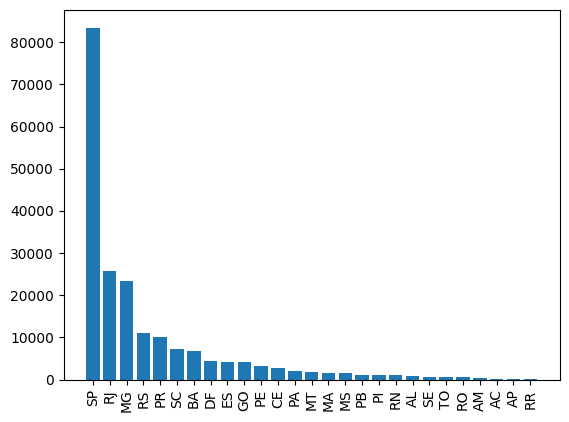

In [2]:
query = """select  customer_state , count(customer_id)
            from customers 
            Group by customer_state
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data,columns = ["State","Customers"])
df = df.sort_values(by = "Customers", ascending=False)

plt.bar(df["State"],df["Customers"])
plt.xticks(rotation = 90)
plt.show()

# Calculate the number of orders per month in 2018.

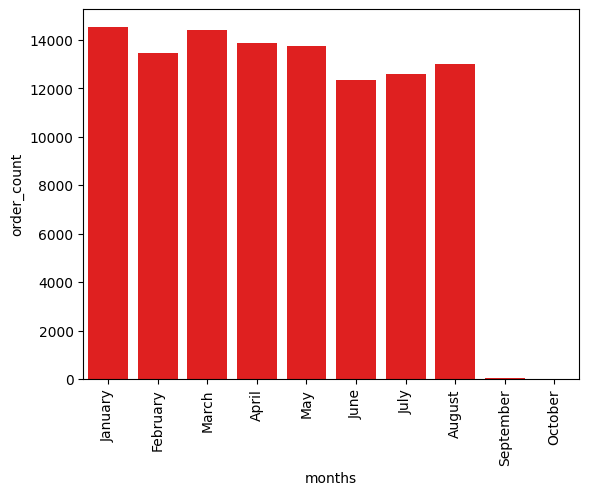

In [15]:
query = """select monthname(order_purchase_timestamp) months,count(order_id)  order_count
from orders where year(order_purchase_timestamp) = 2018
group by months
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=["months","order_count"])
o =["January","February","March","April","May","June","July","August","September","October"]
sns.barplot(x=df["months"],y=df["order_count"], data=df, order=o, color="red")
plt.xticks(rotation=90)
plt.show()

# Find the average number of products per order, grouped by customer city.

In [20]:
query = """with count_per_order as 
(SELECT orders.order_id, orders.customer_id, count(order_items.order_id) as oc
FROM orders JOIN 	order_items
ON orders.order_id = order_items.order_id
GROUP BY orders.order_id, orders.customer_id)

SELECT customers.customer_city, round(avg(count_per_order.oc),2) average_orders
from customers join count_per_order
on customers.customer_id = count_per_order.customer_id
group by customers.customer_city order by average_orders desc
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns=["customer_city","average_orders"])
df.head(10)

,customer_city,average_orders
0,padre carvalho,14.00
1,celso ramos,13.00
2,datas,12.00
3,candido godoi,12.00
4,matias olimpio,10.00
5,cidelandia,8.00
6,picarra,8.00
7,morro de sao paulo,8.00
8,teixeira soares,8.00
9,curralinho,8.00


# Calculate the percentage of total revenue contributed by each product category.

In [23]:
query = """select products.product_category category, 
round((sum(payments.payment_value)/(select sum(payment_value) from payments))*100,2) sales_percentage
from products join order_items
on products.product_id = order_items.product_id
join payments 
on payments.order_id = order_items.order_id
Group by category order by sales_percentage desc;
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data,columns=["Category","Sales_percentage"])
df.head(10)

,Category,Sales_percentage
0,bed table bath,21.40
1,HEALTH BEAUTY,20.71
2,computer accessories,19.81
3,Furniture Decoration,17.87
4,Watches present,17.86
5,sport leisure,17.39
6,housewares,13.68
7,automotive,10.65
8,Garden tools,10.47
9,Cool Stuff,9.74


# Identify the correlation between product price and the number of times a product has been purchased.

In [10]:
query = """select products.product_category, count(order_items.product_id) product_count,
round(avg(order_items.price),2) average_price
from products join order_items
on products.product_id = order_items.product_id
where products.product_category is not null
group by products.product_category order by average_price desc
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data,columns=["Category","Order_count","Price"])
df.head(10)
arr1 = df["Order_count"]
arr2 = df["Price"]

np.corrcoef([arr1,arr2])

array([[ 1.        , -0.10625383],
       [-0.10625383,  1.        ]])

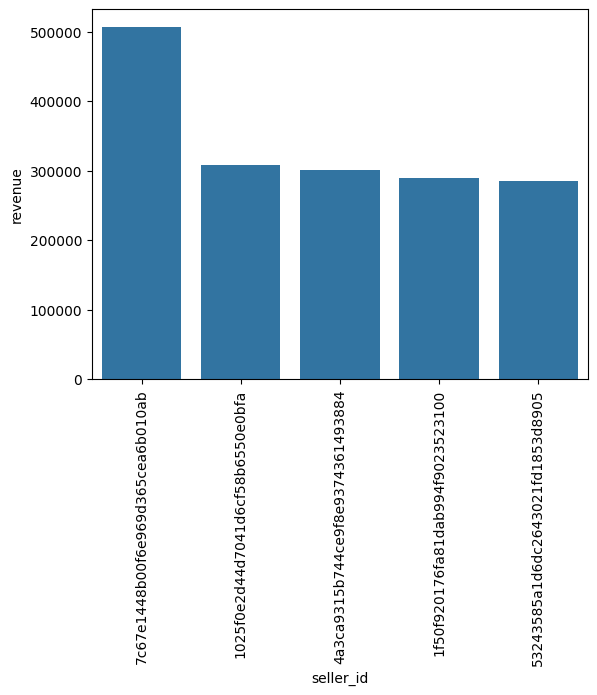

In [22]:
query = """select *, dense_rank() over(order by revenue desc) as rn from
(select order_items.seller_id, round(sum(payments.payment_value),2) revenue
from order_items join payments
on order_items.order_id = payments.order_id
group by order_items.seller_id) as a
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns = ["seller_id","revenue","rank"])
df = df.head(5)
sns.barplot(x = "seller_id", y = "revenue", data =df)
plt.xticks(rotation = 90)
plt.show()

# Calculate the moving average of order values for each customer over their order history.

In [25]:
query = """select customer_id, order_purchase_timestamp,
avg(payment) over(partition by customer_id order by order_purchase_timestamp
rows between 2 preceding and current row) as mov_avg
from
(select orders.customer_id, orders.order_purchase_timestamp,
payments.payment_value payment
from payments join orders
on payments.order_id = orders.order_id) as a;
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns = ["customer_id", "purchase_time", "average"])
df.head(10)

,customer_id,purchase_time,average
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.739998
1,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.739998
2,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,67.410004
3,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,67.410004
4,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,195.419998
5,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,195.419998
6,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,179.350006
7,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,179.350006
8,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,107.010002
9,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,107.010002


# Calculate the cumulative sales per month for each year.

In [26]:
query = """select years, months,payment, sum(payment)
over(order by years, months) cumulative_sales from
(select year(orders.order_purchase_timestamp) as years,
month(orders.order_purchase_timestamp) as months,
round(sum(payments.payment_value),2) as payment from orders join payments 
on orders.order_id = payments.order_id
group by years, months order by years , months) as a;
"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns = ["years", "months", "payment","cumulative_sales"])
df.head(10)

,years,months,payment,cumulative_sales
0,2016,9,504.48,504.48
1,2016,10,118180.96,118685.44
2,2016,12,39.24,118724.68
3,2017,1,276976.08,395700.76
4,2017,2,583816.02,979516.78
5,2017,3,899727.20,1879243.98
6,2017,4,835576.06,2714820.04
7,2017,5,1185837.64,3900657.68
8,2017,6,1022552.76,4923210.44
9,2017,7,1184765.84,6107976.28


# Calculate the year-over-year growth rate of total sales.

In [8]:
query = """with a as(select year(orders.order_purchase_timestamp) as years,
round(sum(payments.payment_value),2) as payment from orders join payments 
on orders.order_id = payments.order_id
group by years order by years)

select years, ((payment - lag(payment,1) over(order by years))/
lag(payment,1) over(order by years)) * 100 from a"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns = ["years","yoy % growth"])
df

,years,yoy % growth
0,2016,NaN
1,2017,12112.703761
2,2018,20.000924


# Calculate the retention rate of customers, defined as the percentage of customers who make another purchase within 6 months of their first purchase.

In [10]:
query = """with a as (select customers.customer_id ,
min( orders.order_purchase_timestamp) first_order
from customers join orders
on customers.customer_id = orders.customer_id
group by customers.customer_id),

b as(select a.customer_id, count(distinct orders.order_purchase_timestamp) next_order
from a join orders 
on orders.customer_id = a.customer_id
and orders.order_purchase_timestamp > first_order
and orders.order_purchase_timestamp <
date_add(first_order ,interval 1 month)
group by a.customer_id)

select 100 * (count(distinct a.customer_id)/ count(distinct b.customer_id)) as retention
from a left join b 
on a.customer_id = b.customer_id;"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data, columns = ["Retention rate"])
df
print("Since none of our customer is repeated so the value is none")

Since none of our customer is repeated so the value is none


# Identify the top 3 customers who spent the most money in each year.

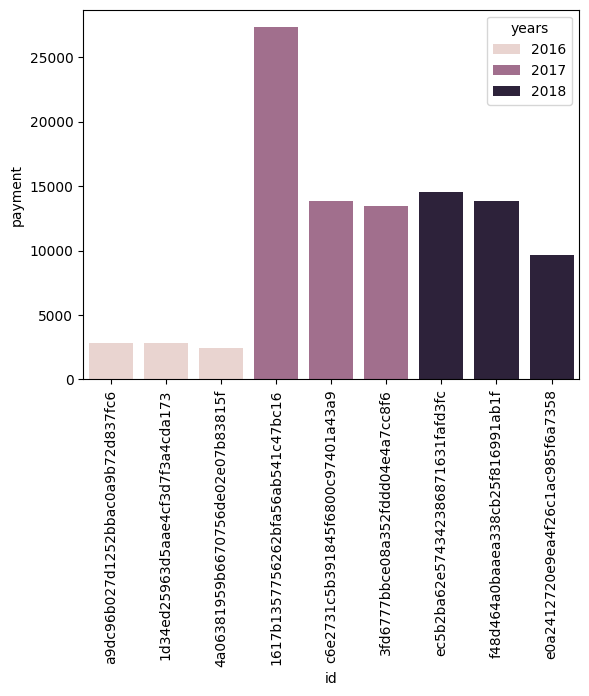

In [16]:
query = """select years, customer_id, payment, d_rank
from
(select year(orders.order_purchase_timestamp) as years,
orders.customer_id,
round(sum(payments.payment_value),2) as payment ,
dense_rank() over(partition by  year(orders.order_purchase_timestamp) order by sum(payments.payment_value) desc) d_rank
from orders join payments 
on orders.order_id = payments.order_id
group by years ,orders.customer_id) as a
where d_rank <= 3"""

cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["years", "id", "payment", "rank"])
sns.barplot(x = "id", y = "payment", data = df, hue = "years")
plt.xticks(rotation = 90)
plt.show()